# Curating samples from the xView 

- sample from promising images
- cross-check with existing annotations
- output for annotating the (missing label) 'road'


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from functools import partial

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geometry as sgeo
import src.sampling as ssam

## Namespace set up, e.g. point to data, local functions

In [3]:
data_path = '../data/xView/train_images-subset/'
label_file = '../data/xView/xView_train.geojson'
labelnames_file = '../data/xView/xView_labelnames.pickle'

out_path = '../data/xView/to_annotate/'
resolution = 128

In [4]:
def add_feature_var( df_, image_, add_ = 2):
    df_['bbox_np_'] = df['bbox_np'].map(
        lambda x: [x[0] - add_, x[1] - add_, x[2] + add_, x[3] + add_]
    )
    df_['feature_var'] = df_['bbox_np_'].map(
        lambda x: sgeo.crop_to_bbox( image_, x).var()
    )
    return df_

def intersecting_df_slice( df_, bbox_np):
    return df_.loc[ 
        df_[ 'bbox_np'].apply( lambda x: sgeo.get_area( sgeo.intersection( bbox_np, x))) > 0, :
    ]

def save_to_annotate( image_, dfs_row, df_, res= 128, out_path= None):
    """
    With image, the candidate sample location, and reference existing annotations (in a dataframe) for 
    that image, create a ready-to-annotate sample (that is the res-by-res with wider box around for
    visual inspection, for easier identification of roads; bbox is drawn around the target sample).
    Also, cross-check with existing annotations (cars & buildings), and correct as needed for our 
    purpose (e.g. for a car it needs to be)
    """
    name_, bbox_context, bbox_in_context, bbox_np = dfs_row[['image','bbox_context','bbox_in_context','bbox_np']]
    df__ = intersecting_df_slice( df_, bbox_np)
    intersection_ = partial( sgeo.intersection, bbox_np)
    dfa = pd.DataFrame( {
        'car_flag': df__['car_flag'].values,
        'bus_truck_flag': df__['bus_truck_flag'].values,
        'building_flag': df__['building_flag'].values,
        'feature_area': df__['feature_area'].values,
        'intersection':df__['bbox_np'].map( intersection_)
    })
    dfa['intersection_area'] = dfa['intersection'].map( sgeo.get_area).values
    built_area = dfa.loc[ dfa['building_flag']==1, 'intersection_area'].sum() / (res**2)
    n_cars = len(
        dfa.loc[ (dfa['car_flag']==1) & ( dfa['intersection_area'] > 0.9 * dfa['feature_area']) ]
    )
    n_bus_trucks = len(
        dfa.loc[ (dfa['bus_truck_flag']==1) & ( dfa['intersection_area'] > 0.9 * dfa['feature_area']) ]
    )
    crop = sgeo.crop_to_bbox( image_, bbox_context).copy()
    crop = splo.draw_bbox( crop, bbox_in_context)
    if n_cars + n_bus_trucks > 0:
        crop = splo.mark_c( crop)
    if built_area > 0.25:
        crop = splo.mark_b( crop)
    if out_path is not None:
        # for whatever reasons, pyplot-saved images do not work with pyannotate but PIL ones do:
        Image.fromarray( crop).save(f'{out_path}{name_}')
        return built_area, n_cars, n_bus_trucks
    else:
        return crop, df__, dfa

## Interactive processing - load the dataset annotations, filter, sample etc


In [6]:
df = sdut.parse_xView_geojson( label_file, labelnames_file)
df.head(3)

,cat_id,index_right,image_id,feature_id,bbox,cat,bbox_np,feature_area,building_flag,car_flag,bus_truck_flag
0,73,2356,2355.tif,374410,"[2712, 1145, 2746, 1177]",Building,"(1145, 2712, 1177, 2746)",1088,1,0,0
1,73,2356,2355.tif,394393,"[2720, 2233, 2760, 2288]",Building,"(2233, 2720, 2288, 2760)",2200,1,0,0
2,73,2356,2355.tif,374031,"[2687, 1338, 2740, 1399]",Building,"(1338, 2687, 1399, 2740)",3233,1,0,0


In [7]:
dfg = df.groupby('image_id').agg({
    'cat_id': [ len, lambda x: len(set(x)), 
                lambda x: len([y for y in x if y in sdut.xView_car_set]),
                lambda x: len([y for y in x if y in sdut.xView_bus_truck_set]),
                lambda x: len([y for y in x if y == 73])]
}).droplevel(level=0,axis=1).rename( 
    columns= {'<lambda_0>': 'n_cats', 'len': 'n_labels', '<lambda_1>':'n_cars', '<lambda_2>':'n_bus_trucks', '<lambda_3>':'n_buildings'}
)
dfg.head(3)

,n_labels,n_cats,n_cars,n_bus_trucks,n_buildings
image_id,,,,,
10.tif,63,7,2,1,44
100.tif,135,3,62,7,66
102.tif,1965,9,346,25,1563


Now that we have some high-level understanding can choose poss interesting images - **NOTE** various options below

In [8]:
target_ims = dfg.loc[ dfg['n_cars']+dfg['n_bus_trucks']>300].index.tolist()
target_ims = [x for x in target_ims if os.path.exists(f'{data_path}{x}')]
print(f'{len(target_ims)} images')

215 images


In [16]:
target_ims = dfg.loc[ (dfg['n_cars']+dfg['n_bus_trucks']>50) & (dfg['n_buildings'] <100)].index.tolist()
target_ims = [x for x in target_ims if os.path.exists(f'{data_path}{x}')]
print(f'{len(target_ims)} images')

81 images


In [9]:
which_im = 25
sample_im_name = target_ims[ which_im]

In [20]:
sample_im_name = '43.tif'

In [21]:
sample_im_name_ = sample_im_name.split('.tif')[0]
df_ = df.loc[ df['image_id']== sample_im_name].copy()
image_ = np.array( Image.open(f'{data_path}{sample_im_name}'))
df_ = add_feature_var( df_, image_)
xmax, ymax, _ = image_.shape
figsize = ( int(xmax / 400), int( ymax/ 400))
sample_im_name

C:\Users\daago\AppData\Local\Temp\ipykernel_10108\2870975036.py:6: RuntimeWarning: Degrees of freedom <= 0 for slice
  lambda x: sgeo.crop_to_bbox( image_, x).var()
C:\Users\daago\.conda\envs\clear-dear\Lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\daago\.conda\envs\clear-dear\Lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


'43.tif'

<Axes: >

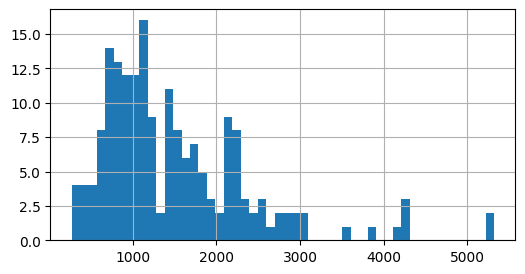

In [22]:
_ = plt.subplots( figsize= (6,3))
df_.loc[ df_['car_flag']==1, 'feature_var'].hist( bins=50)

### Center on cars option

One possibility is to select cars, and center the bounding box on them. We can't do **just** that, as then we'd always have roads with cars on them, so we at least need to mix in random sampling (e.g. sample with cars where scene is _not_ from a city, to avoid oversampling plain fields; and sample randomly where scene is _urban_ or _mixed_)

In [23]:
visible_cars = ((df_['car_flag'] + df_['bus_truck_flag']) > 0) & (df_['feature_area']>100) & (df_['feature_var']>900)

# instead of random:
dfs = pd.DataFrame({
    'xs' : df_.loc[ visible_cars, 'bbox_np'].map( lambda x: x[0] + int((x[2]-x[0])/2)),
    'ys' : df_.loc[ visible_cars, 'bbox_np'].map( lambda x: x[1] + int((x[3]-x[1])/2))
})
border = int( resolution / 2)
# need to exclude too close to border:
to_drop = dfs.loc[ 
    (dfs['xs'] < border+1) | (dfs['ys'] < border+1) | (dfs['xs'] > xmax-border-1) | (dfs['ys'] > ymax-border-1)
].index
dfs.drop( labels= to_drop, inplace= True)
dfs.reset_index( inplace= True, drop=True)

dfs = ssam.prep_samples_for_annot( 
    (xmax, ymax), sample_im_name_, 0, shift_min= 40,res= resolution, seed= 0, rounds= 2, df= dfs 
)
print( dfs.shape)

dfs.head(2)

(83, 12)


,xs,ys,buildings,roads,cars,bbox_np,image,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks
0,70,258,-1,-1,-1,"[6, 194, 134, 322]",tif43_x70_y258.png,"[0, 130, 256, 386]","[6, 64, 134, 192]",NaN,NaN,NaN
1,74,608,-1,-1,-1,"[10, 544, 138, 672]",tif43_x74_y608.png,"[0, 480, 256, 736]","[10, 64, 138, 192]",NaN,NaN,NaN


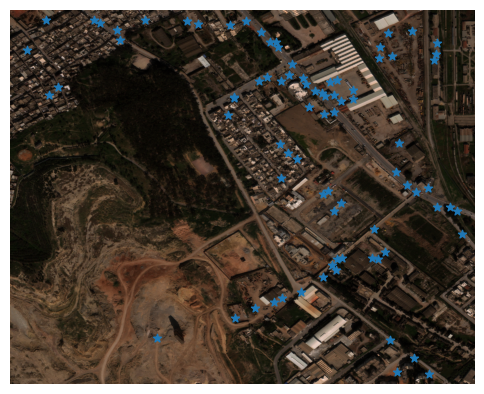

In [24]:
ax = splo.plot_single(image_, figsize= figsize)
ax.scatter(dfs['ys'], dfs['xs'], marker='*')

### Add also random samples:

In [25]:
dfs2 = ssam.prep_samples_for_annot( 
    (xmax, ymax), sample_im_name_, shift_min= 30, res= resolution, seed= 13, num_samp= 500- len(dfs)
)
print( dfs2.shape)
dfs2.head(2)

(410, 12)


,xs,ys,buildings,roads,cars,bbox_np,image,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks
0,79,948,-1,-1,-1,"[15, 884, 143, 1012]",tif43_x79_y948.png,"[0, 820, 256, 1076]","[15, 64, 143, 192]",NaN,NaN,NaN
1,80,1444,-1,-1,-1,"[16, 1380, 144, 1508]",tif43_x80_y1444.png,"[0, 1316, 256, 1572]","[16, 64, 144, 192]",NaN,NaN,NaN


In [26]:
dfs = ssam.filter_xy( pd.concat([dfs, dfs2]), shift_min= 20, rounds=2)
dfs.reset_index( inplace= True, drop= True)
dfs.shape

(491, 12)

#### next cell - use for filtering out chunks of image only

In [32]:
keep = ~((dfs['xs'] >1800) & (dfs['ys'] <1500))

In [14]:
keep = dfs['xs']>0

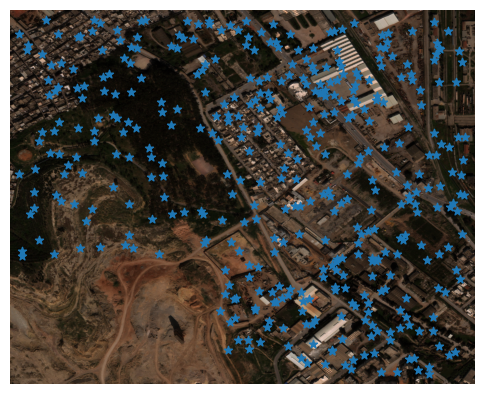

In [33]:
ax = splo.plot_single(image_, figsize= figsize)
ax.scatter(dfs.loc[keep,'ys'], dfs.loc[keep,'xs'], marker='*')

In [34]:
dfs = dfs.loc[ keep]
len(dfs), len(dfs.image.unique())

(414, 414)

In [35]:
dfs.head(2)

,xs,ys,buildings,roads,cars,bbox_np,image,bbox_context,bbox_in_context,built_area,n_cars,n_bus_trucks
0,70,258,-1,-1,-1,"[6, 194, 134, 322]",tif43_x70_y258.png,"[0, 130, 256, 386]","[6, 64, 134, 192]",NaN,NaN,NaN
1,74,608,-1,-1,-1,"[10, 544, 138, 672]",tif43_x74_y608.png,"[0, 480, 256, 736]","[10, 64, 138, 192]",NaN,NaN,NaN


<Axes: >

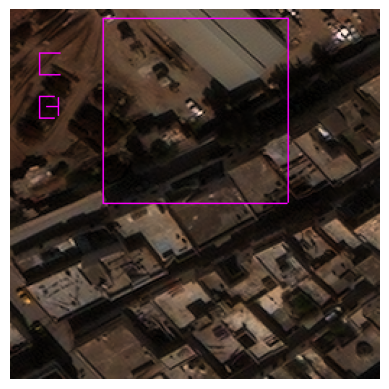

In [36]:
crop, df__, dfa = save_to_annotate( image_, dfs.loc[dfs.index[0]], df_)
splo.plot_single( crop)

### next cell outputs to `data/xView/to_annotate` folder

In [37]:
start = tm.time()

for idx in dfs.index:
    dfs.loc[ idx, ['built_area','n_cars','n_bus_trucks']] = save_to_annotate( image_, dfs.loc[idx], df_, out_path= out_path)

dfs.to_csv(f'{out_path}labels.csv', index= False)    

print(f'Took {np.round( (tm.time() - start)/60, 2)} mins; output {len(dfs)}.')

Took 0.15 mins; output 414.


In [39]:
os.listdir('../data/xView/to_annotate/')[91]

'tif43_x151_y2351.png'